# Test of the Hyperview dataset

Regression task to estimate soil parameters (4)

In [14]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

Adding /home/ando to sys.path


## Create splits 

If using for the first time: will save the splits to the root/splits directory

In [ ]:
from geofm_src.datasets.hyperview_wrapper import HyperviewBenchmark

dataset = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', create_splits=True)


/data/panopticon/datasets/hyperview/splits/train.csv


In [72]:
from src.datasets.hyperview_wrapper import HyperviewBenchmark
ds_hyp = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', split='train')
ds_hyp.df




/data/panopticon/datasets/hyperview/splits/train.csv


,sample_index,P,K,Mg,pH,file_paths
0,1294,57.8,181.0,158.0,6.50,/data/panopticon/datasets/hyperview/train_data...
1,1374,68.0,206.0,142.0,6.80,/data/panopticon/datasets/hyperview/train_data...
2,1286,48.8,176.0,161.0,6.60,/data/panopticon/datasets/hyperview/train_data...
3,684,37.2,229.0,155.0,7.00,/data/panopticon/datasets/hyperview/train_data...
4,260,40.0,191.0,242.0,6.60,/data/panopticon/datasets/hyperview/train_data...
...,...,...,...,...,...,...
1293,367,40.6,186.0,140.0,6.97,/data/panopticon/datasets/hyperview/train_data...
1294,1033,60.1,187.0,154.0,6.80,/data/panopticon/datasets/hyperview/train_data...
1295,609,37.6,208.0,137.0,7.40,/data/panopticon/datasets/hyperview/train_data...
1296,133,77.8,229.0,208.0,6.70,/data/panopticon/datasets/hyperview/train_data...


img: (150, 11, 11), mask: (150, 11, 11)
img: (150, 11, 11), mask: (150, 11, 11)
torch.Size([150, 11, 11]) tensor([115., 261., 195.,   7.], dtype=torch.float64)


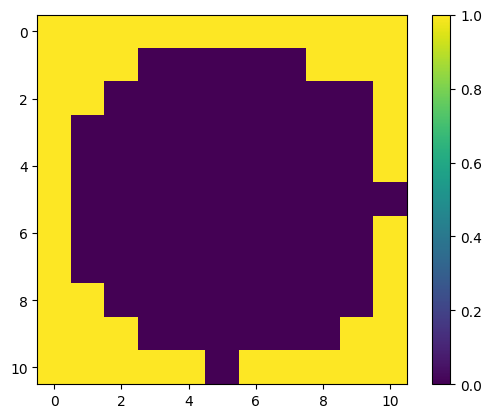

In [95]:
import random 
import matplotlib.pyplot as plt

image, label = ds_hyp[random.randint(0, len(ds_hyp))]


band_id = 100

(image,mask), _  = ds_hyp[20]
print(image.shape, label)
sample = image[band_id]

# image = (image - image.min()) / (image.max() - image.min())

# ds_hyp.plot(image)

plt.imshow(mask[128])
#show colorbar
plt.colorbar()


In [91]:
#calculate the mode across the channels
import torch
mode = torch.mode(mask, dim=0)
mode


torch.return_types.mode(
values=tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True],
        [ True,  True,  True, False, False, False, False, False,  True,  True,
          True],
        [ True,  True, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
         False],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True,  True, False, False, False, False, False, False, False, False,
          True],
        [ True,  True,  True, False, False, False, False, False, False,  True,
          True],
        

In [68]:
sample

masked_array(
  data=[[--, --, --, --, --, --, --, --, --, --, --],
        [--, --, --, 2752, 2432, 2471, 2200, 2077, --, --, --],
        [--, --, 3269, 2360, 2597, 2402, 2123, 2035, 2013, 1505, --],
        [--, 3305, 3093, 2222, 2396, 2437, 2209, 2226, 2092, 1804, --],
        [--, 3146, 2947, 2142, 2284, 2500, 2506, 2292, 2241, 1835, --],
        [--, 3130, 2724, 2179, 2340, 2601, 2405, 2147, 2073, 2021, 2003],
        [--, 3255, 2847, 2259, 2488, 2608, 2485, 2205, 2059, 2067, --],
        [--, 3150, 2768, 2276, 2358, 2616, 2479, 2294, 1799, 1781, --],
        [--, --, 2729, 2212, 2253, 2745, 2548, 2270, 1800, 1926, --],
        [--, --, --, 2267, 2324, 2743, 2663, 2498, 2140, --, --],
        [--, --, --, --, --, 2790, --, --, --, --, --]],
  mask=[[ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True, False, False, False, False, False,  True,
          True,  True],
        [ True,  True, False, False, False, False, 

/data/panopticon/datasets/hyperview/splits/val.csv
torch.Size([150, 11, 11]) tensor([ 54.1000, 183.0000, 150.0000,   6.9000], dtype=torch.float64)


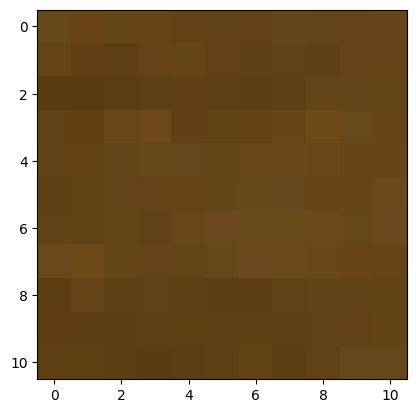

In [44]:
from src.datasets.hyperview_wrapper import HyperviewBenchmark

ds_hyp = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', split='val')

image, label = ds_hyp[random.randint(0, len(ds_hyp))]
print(image.shape, label)

image = (image - image.min()) / (image.max() - image.min())

ds_hyp.plot(image)




/data/panopticon/datasets/hyperview/splits/test.csv
torch.Size([150, 46, 48]) tensor([ 63.8000, 316.0000, 161.0000,   6.4000], dtype=torch.float64)


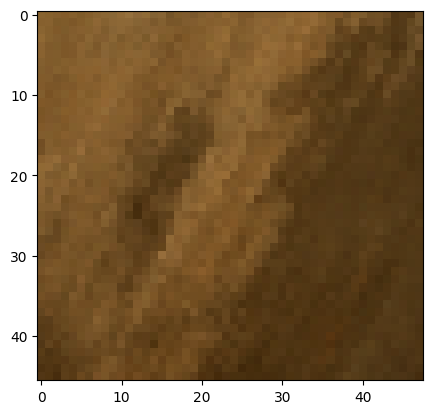

In [50]:
from src.datasets.hyperview_wrapper import HyperviewBenchmark

ds_hyp = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', split='test')
image, label = ds_hyp[random.randint(0, len(ds_hyp))]
print(image.shape, label)

image = (image - image.min()) / (image.max() - image.min())

ds_hyp.plot(image)




# Check dataset 

In [125]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('src/configs/dataset/hyperview_all.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

[HyperviewBenchmark] Building dataset for split: train
[HyperviewBenchmark] Building dataset for split: val
[HyperviewBenchmark] Building dataset for split: test


torch.Size([150, 224, 224]) tensor([ 68.8000, 301.0000, 131.0000,   6.8000], dtype=torch.float64)


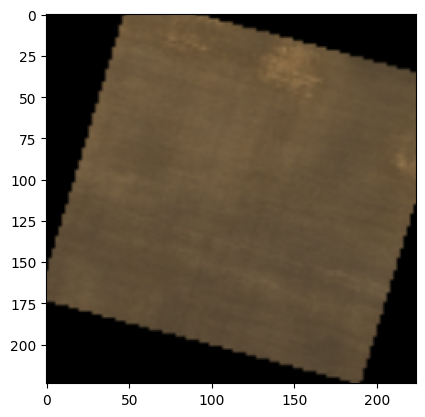

In [132]:
image, label = train_ds[random.randint(0, len(train_ds))]
print(image.shape, label)

image = (image - image.min()) / (image.max() - image.min())

train_ds.plot(image)


# Calculate the mean and std of the dataset using train and val splits

100%|██████████| 174/174 [00:04<00:00, 37.91it/s]


Mean per channel: tensor([0.3911, 0.3909, 0.3902, 0.3909, 0.3917, 0.3934, 0.3941, 0.3938, 0.3935,
        0.3930, 0.3927, 0.3926, 0.3925, 0.3932, 0.3937, 0.3938, 0.3941, 0.3944,
        0.3947, 0.3943, 0.3942, 0.3944, 0.3949, 0.3956, 0.3956, 0.3956, 0.3958,
        0.3958, 0.3960, 0.3961, 0.3964, 0.3965, 0.3966, 0.3964, 0.3961, 0.3958,
        0.3955, 0.3953, 0.3951, 0.3951, 0.3952, 0.3951, 0.3951, 0.3951, 0.3952,
        0.3952, 0.3952, 0.3950, 0.3949, 0.3948, 0.3948, 0.3949, 0.3951, 0.3953,
        0.3956, 0.3958, 0.3958, 0.3957, 0.3953, 0.3947, 0.3940, 0.3931, 0.3921,
        0.3911, 0.3900, 0.3891, 0.3878, 0.3865, 0.3864, 0.3888, 0.3934, 0.3988,
        0.4028, 0.4035, 0.4008, 0.3955, 0.3897, 0.3824, 0.3745, 0.3665, 0.3584,
        0.3506, 0.3431, 0.3357, 0.3285, 0.3217, 0.3157, 0.3107, 0.3070, 0.3047,
        0.3035, 0.3031, 0.3031, 0.3030, 0.3029, 0.3028, 0.3027, 0.3028, 0.3031,
        0.3034, 0.3038, 0.3042, 0.3046, 0.3049, 0.3052, 0.3055, 0.3059, 0.3062,
        0.3065, 0.3069

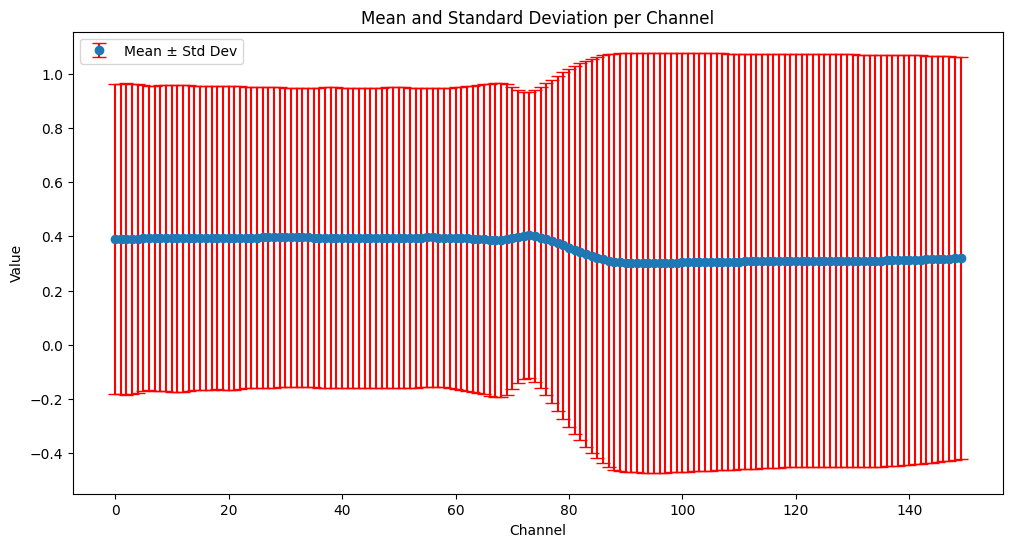

In [188]:
import numpy as np
import torch
from tqdm import tqdm

# calculate the channel-wise mean and std of the train set
#ARTIFICALLY turn off normalize before you do this obvs!

# Image stats
C = train_ds.num_channels
sum_per_channel = torch.zeros(C)
sum_of_squares_per_channel = torch.zeros(C)
num_samples = 0

#Label stats
sum_per_label = torch.zeros(4)
sum_of_squares_per_label = torch.zeros(4)
labels_max = torch.zeros(4)
labels_min = torch.ones(4) * 10000
num_images = 0

#train set
for i in tqdm(range(len(train_ds))):

    img, label = train_ds[i]
    # Accumulate sum and sum of squares
    sum_per_channel += img.view(C, -1).sum(dim=1)
    sum_of_squares_per_channel += (img.view(C, -1) ** 2).sum(dim=1)
    num_samples += img.shape[1] * img.shape[2]

    sum_per_label += label
    sum_of_squares_per_label += label ** 2
    num_images += 1
    labels_max = torch.max(labels_max, label)
    labels_min = torch.min(labels_min, label)
    
# val set
for i in tqdm(range(len(val_ds))):
    img, label = val_ds[i]
    # Accumulate sum and sum of squares
    sum_per_channel += img.view(C, -1).sum(dim=1)
    sum_of_squares_per_channel += (img.view(C, -1) ** 2).sum(dim=1)
    num_samples += img.shape[1] * img.shape[2]
    num_images += 1
    labels_max = torch.max(labels_max, label)
    labels_min = torch.min(labels_min, label)

# Compute mean and standard deviation
mean_per_channel = sum_per_channel / num_samples
std_per_channel = torch.sqrt(sum_of_squares_per_channel / num_samples - mean_per_channel ** 2)

mean_per_label = sum_per_label / num_images
std_per_label = torch.sqrt(sum_of_squares_per_label / num_images - mean_per_label ** 2)

print("Mean per channel:", mean_per_channel)
print("Standard deviation per channel:", std_per_channel)
print("Number of samples:", num_samples)

print("Mean per label:", mean_per_label)
print("Standard deviation per label:", std_per_label)
print("Max per label:", labels_max)
print("Min per label:", labels_min)
print("Number of images:", num_images)

channels = np.arange(C)
mean_values = mean_per_channel.numpy()
std_values = std_per_channel.numpy()

plt.figure(figsize=(12, 6))
plt.errorbar(channels, mean_values, yerr=std_values, fmt='o', ecolor='r', capsize=5, label='Mean ± Std Dev')
plt.xlabel('Channel')
plt.ylabel('Value')
plt.title('Mean and Standard Deviation per Channel')
plt.legend()
plt.show()

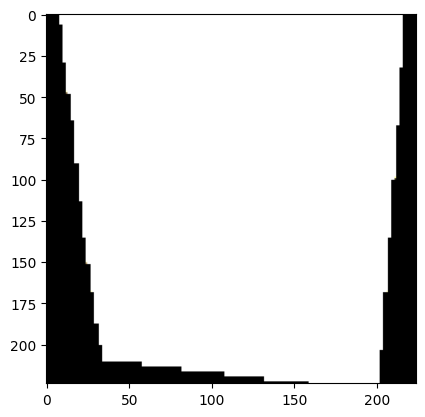

In [140]:
train_ds.plot(img)

# Check if normalize is working

In [20]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/hyperview_10b.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

[ClsDataAugmentation: train] Sampling channels: [6, 18, 42, 59, 70, 82, 102, 109, 126, 144]
[ClsDataAugmentation: val/test] Sampling channels: [6, 18, 42, 59, 70, 82, 102, 109, 126, 144]
[HyperviewBenchmark] Building dataset for split: train
[HyperviewBenchmark] Building dataset for split: val
[HyperviewBenchmark] Building dataset for split: test


In [26]:
import random
image, label = train_ds[random.randint(0, len(test_ds))]
print(image.shape, label)

print(image.min(), image.max())

# image = (image - image.min()) / (image.max() - image.min())

# train_ds.plot(image)


torch.Size([10, 224, 224]) tensor([0.5843, 0.0576, 0.9266, 0.2807])
tensor(-1.2017) tensor(1.7332)


## Channel Binning

In [13]:
# import numpy as np
#set seed
np.random.seed(42)

num_channels = 150
K = 10
# Calculate bin size
bin_size = num_channels // K
# Create bins and select random values from each
selected_channels = []
for i in range(K):
    start = i * bin_size
    end = start + bin_size if i < K-1 else num_channels  # Handle last bin differently
    selected_channels.append(np.random.randint(start, end))

print(f"Selected channels: {sorted(selected_channels)}")


Selected channels: [6, 18, 42, 59, 70, 82, 102, 109, 126, 144]


In [27]:
# import numpy as np
#set seed
np.random.seed(42)

num_channels = 202
K = 10
# Calculate bin size
bin_size = num_channels // K
# Create bins and select random values from each
selected_channels = []
for i in range(K):
    start = i * bin_size
    end = start + bin_size if i < K-1 else num_channels  # Handle last bin differently
    selected_channels.append(np.random.randint(start, end))

print(f"Selected channels: {sorted(selected_channels)}")


Selected channels: [6, 39, 54, 70, 87, 106, 138, 150, 170, 200]
